In [41]:
from mobgap.data import GenericMobilisedDataset
from mobgap.pipeline import MobilisedPipelineHealthy

In [64]:
import os
def get_paths_with_extension(extension):
    paths = []
    dataset_folder = os.path.join(os.getcwd())

    for root, dirs, files in os.walk(dataset_folder):
        for file in files:
            if file.lower().endswith(extension):
                path = os.path.join(root, file)
                if not ".venv" in path:
                    paths.append(path)
    
    return paths

cwa_files = get_paths_with_extension(".cwa")

print("Here is the list of all our \".cwa\" files:")
print(cwa_files)

Here is the list of all our ".cwa" files:
['C:\\Users\\ac4jmi\\PycharmProjects\\mobilise-d_mobgap_tutorial\\6032032_0000000000.cwa']


In [65]:
from openmovement.load import CwaData
if len(cwa_files) > 1:
    print("Error, more than 1 \".cwa\" file in your folder, make sure you just have your file from today in there!")
else:
    with CwaData(cwa_files[0], include_time = True, include_gyro=True, include_temperature=False, include_light=False) as cwa_data:
        samples = cwa_data.get_samples()

# note that we use display to make things look nice in JuPyter, rather than print. 
# If you want to see why, try replacing the following "display" with "print"...
display(samples.head(10))

,time,accel_x,accel_y,accel_z,gyro_x,gyro_y,gyro_z
0,2025-08-07 11:11:45.309753344,-0.347900,1.341309,0.771973,-42.480469,70.373535,42.419434
1,2025-08-07 11:11:45.319920384,-0.504395,1.531250,0.746826,-28.442383,92.346191,15.808105
2,2025-08-07 11:11:45.330087168,-0.416748,1.536377,0.740479,-24.841309,94.116211,-26.123047
3,2025-08-07 11:11:45.340254208,-0.280029,1.444580,0.727539,-13.671875,103.454590,-53.283691
4,2025-08-07 11:11:45.350421248,-0.225098,1.335205,0.615479,-2.807617,115.905762,-63.842773
5,2025-08-07 11:11:45.360588032,-0.092773,1.137939,0.486816,0.061035,115.661621,-63.354492
6,2025-08-07 11:11:45.370755072,0.011230,0.987305,0.354736,3.784180,112.609863,-45.166016
7,2025-08-07 11:11:45.380921856,0.008789,0.889648,0.230957,3.845215,103.576660,-16.418457
8,2025-08-07 11:11:45.391088896,0.020264,0.832520,0.074707,9.704590,93.688965,10.314941
9,2025-08-07 11:11:45.401255936,0.052979,0.833252,-0.035645,29.724121,81.542969,36.010742


<Axes: >

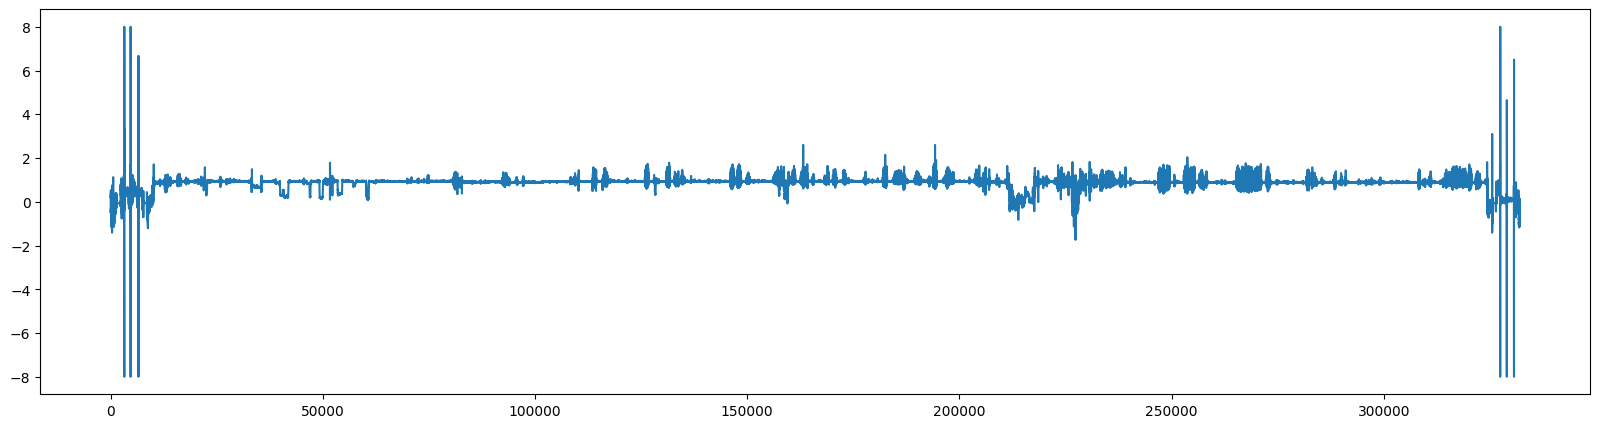

In [66]:
samples["accel_x"].plot(figsize = (20, 5)) # note that figsize contains the x and y sizes for the figure. Have a play with these to see what happens.

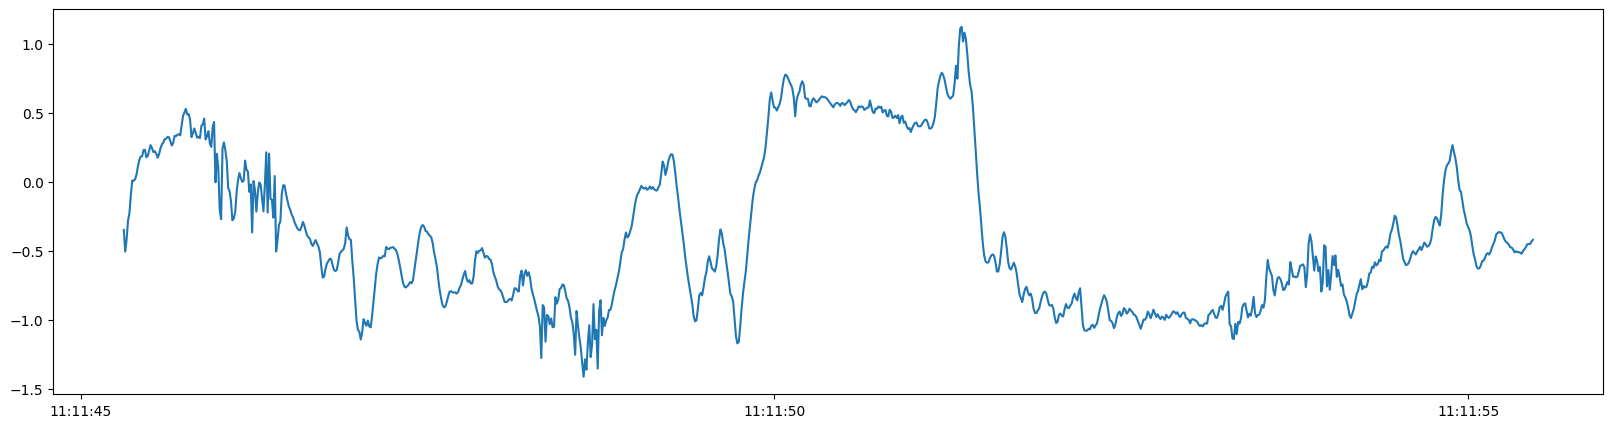

In [67]:
import matplotlib.pyplot as plt    # we'll use matplotlib for this plot

start_id = 0    # the first point we want to plot - feel free to change
end_id = 1000   # the last point we want to plot - feel free to change

samples_to_plot = samples.iloc[start_id:end_id] # here we make a copy of our table, but use iloc to get just the values from the start_id to the end_id

plt.figure(figsize=(20, 5))                                   # first, we tell matplotlib how big the figure will be.
plt.plot(samples_to_plot["time"], samples_to_plot["accel_x"]) # next, we plot the x and y axes as columns from our table
plt.show()                                                    # finally, we show the figure

In [68]:
reformatted_time = samples["time"].astype('int64') // 10**9  # convert nanoseconds to seconds       
reformatted_time = reformatted_time.values.reshape(-1, 1).astype(float)

display(reformatted_time)

array([[1.75456510e+09],
       [1.75456510e+09],
       [1.75456510e+09],
       ...,
       [1.75456848e+09],
       [1.75456848e+09],
       [1.75456848e+09]], shape=(332040, 1))

In [69]:
start_date_time = samples["time"].iloc[0].strftime('%d-%b-%Y %H:%M:%S')
print(start_date_time)

07-Aug-2025 11:11:45


In [70]:
fs = 100#len(samples)/(reformatted_time[-1][0] - reformatted_time[0][0])
print(fs)

100


In [71]:
data = {
    "TimeMeasure1": {
        "Test1": {
            "Trial1": {
                "SU": {
                    "LowerBack": {
                        "Fs": {
                            "Acc": fs,
                            "Gyr": fs
                        },
                        "Acc": samples[["accel_x", "accel_y", "accel_z"]].values.astype(float),
                        "Gyr": samples[["gyro_x", "gyro_y", "gyro_z"]].values.astype(float),
                        "Timestamp": reformatted_time
                    }
                }, 
                "StartDateTime": start_date_time,
                "TimeZone": "Europe/UK"
            }
        }
    }
}

data = {"data": data}

In [72]:
gender = "M"
handedness = "R"
age = 26
weight = 80.4
height = 183
sensor_height = 111

infoForAlgo = {
    "TimeMeasure1": {
        "Subject_ID": "1",
        "Cohort": "HA",
        "Gender": gender,
        "Handedness": handedness,
        "Age": age,
        "Weight": weight,
        "Height": height,
        "SensorHeight": sensor_height,
        "WalkingAid_01": 0,
        "WalkingAid_Side": "",
        "WalkingAid_Description": "",
        "SensorType_SU": "AX6",
        "SensorAttachment_SU": "Body-Worn"
    }
}

infoForAlgo = {"infoForAlgo": infoForAlgo}

In [73]:
current_dir = os.getcwd()                                   # get current working directory (cwd)
target_dir = os.path.join(current_dir, r'Dataset/HA/1')     # define the target directory relative to the current directory
if not os.path.exists(target_dir):                          # check if the folders already exist
   os.makedirs(target_dir)                                  # if they dont, make the folders

In [74]:
from scipy.io import savemat

savemat(target_dir + "\\infoForAlgo.mat", infoForAlgo, do_compression=False)
savemat(target_dir + "\\data.mat", data, do_compression=False)

In [75]:
mat_files = get_paths_with_extension(".mat")
mat_files = [file for file in mat_files if file.endswith("data.mat")]
print(mat_files)
dataset = GenericMobilisedDataset(
    paths_list = mat_files,
    test_level_names = ["TimeMeasure", "Test", "Trial"], # This is the structure (without numbers) of the data inside the data.mat struct.
    measurement_condition = "laboratory",
    parent_folders_as_metadata=["dataset", "cohort", "subject"] # these are the column headings for the metadata, the columns get populated with the folder names.
)

display(dataset)

['C:\\Users\\ac4jmi\\PycharmProjects\\mobilise-d_mobgap_tutorial\\Dataset\\HA\\1\\data.mat']


,dataset,cohort,subject,TimeMeasure,Test,Trial
0,Dataset,HA,1,TimeMeasure1,Test1,Trial1


In [76]:
pipeline = MobilisedPipelineHealthy()
pipeline = pipeline.safe_run(dataset)
print("Pipeline finished running!")

Pipeline finished running!


In [77]:
display(pipeline.aggregated_parameters_) # all parameters across all walking bouts

,wb_all__count,total_walking_duration_min,wb_all__n_raw_initial_contacts__sum,wb_all__duration_s__avg,wb_all__duration_s__p90,wb_all__duration_s__var,wb_all__cadence_spm__avg,wb_all__stride_duration_s__avg,wb_all__cadence_spm__var,wb_all__stride_duration_s__var,...,wb_30__count,wb_30__walking_speed_mps__avg,wb_30__stride_length_m__avg,wb_30__cadence_spm__avg,wb_30__stride_duration_s__avg,wb_30__walking_speed_mps__p90,wb_30__cadence_spm__p90,wb_30__walking_speed_mps__var,wb_30__stride_length_m__var,wb_60__count
all_wbs,48,10.221333,935,9.75,26.058,0.784912,84.937908,1.281919,0.116938,0.153268,...,2,0.946486,1.191954,93.195911,1.218777,1.128594,100.631043,0.340125,0.210325,1


In [78]:
display(pipeline.per_wb_parameters_.head(5))     # first 5 per-walking-bout parameters

,start,end,n_strides,rule_name,rule_obj,duration_s,n_raw_initial_contacts,stride_duration_s,cadence_spm,stride_length_m,walking_speed_mps
wb_id,,,,,,,,,,,
0,92182,93395,14,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",12.13,16,1.527143,71.433869,0.946847,0.580721
1,97000,97422,5,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",4.22,7,1.374000,68.541983,0.568136,0.340453
2,108318,108725,4,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",4.07,6,1.687500,73.310649,0.825835,0.496100
3,109078,109588,4,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",5.10,6,1.475000,65.018471,0.765482,0.432201
4,113602,114385,10,max_break,"MaxBreakCriteria(consider_end_as_break=True, m...",7.83,12,1.170000,87.255415,1.173126,0.875892


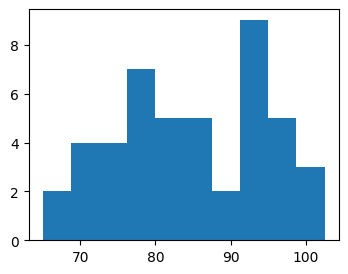

In [79]:
plt.figure(figsize = (4, 3))
plt.hist(pipeline.per_wb_parameters_["cadence_spm"], bins = 10)
plt.show()